In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('/Users/thijsmanuel/Documents/cuhk_classes/4130/term_paper/vinci/Data/hsi_vol.xlsx').set_index('date')
hsi = df['2800.HK']

log_ret = pd.read_excel('/Users/thijsmanuel/Documents/cuhk_classes/4130/term_paper/vinci/Data/hsi_log_ret.xlsx').set_index('date')

In [4]:
back_var = log_ret['2800.HK'].pow(2).rolling(21).sum()  # no shift = trailing window
y_naive = 0.5 * np.log(back_var + 1e-12)

# Align indices (drop NaNs from edges)
mask = hsi.notna() & y_naive.notna()
y_true_aligned = hsi[mask]
y_naive_aligned = y_naive[mask]

y_naive= y_naive_aligned[y_naive_aligned.index >= '2022-01-01']
y_true = y_true_aligned[y_true_aligned.index.isin(y_naive.index)]

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Baseline error
mse = mean_squared_error(y_true, y_naive)
mae = mean_absolute_error(y_true, y_naive)
r2 = r2_score(y_true, y_naive)
print("MSE:", round(mse,3))
print("MAE:", round(mae,3))
print("R2:", round(r2,3))

MSE: 0.146
MAE: 0.287
R2: -0.397


In [5]:
ann_true = np.exp(y_true) * np.sqrt(12) * 100
ann_pred = np.exp(y_naive) * np.sqrt(12) * 100

ann_true = ann_true[ann_true.index >= '2022-01-01']
ann_pred = ann_pred[ann_pred.index.isin(ann_true.index)]

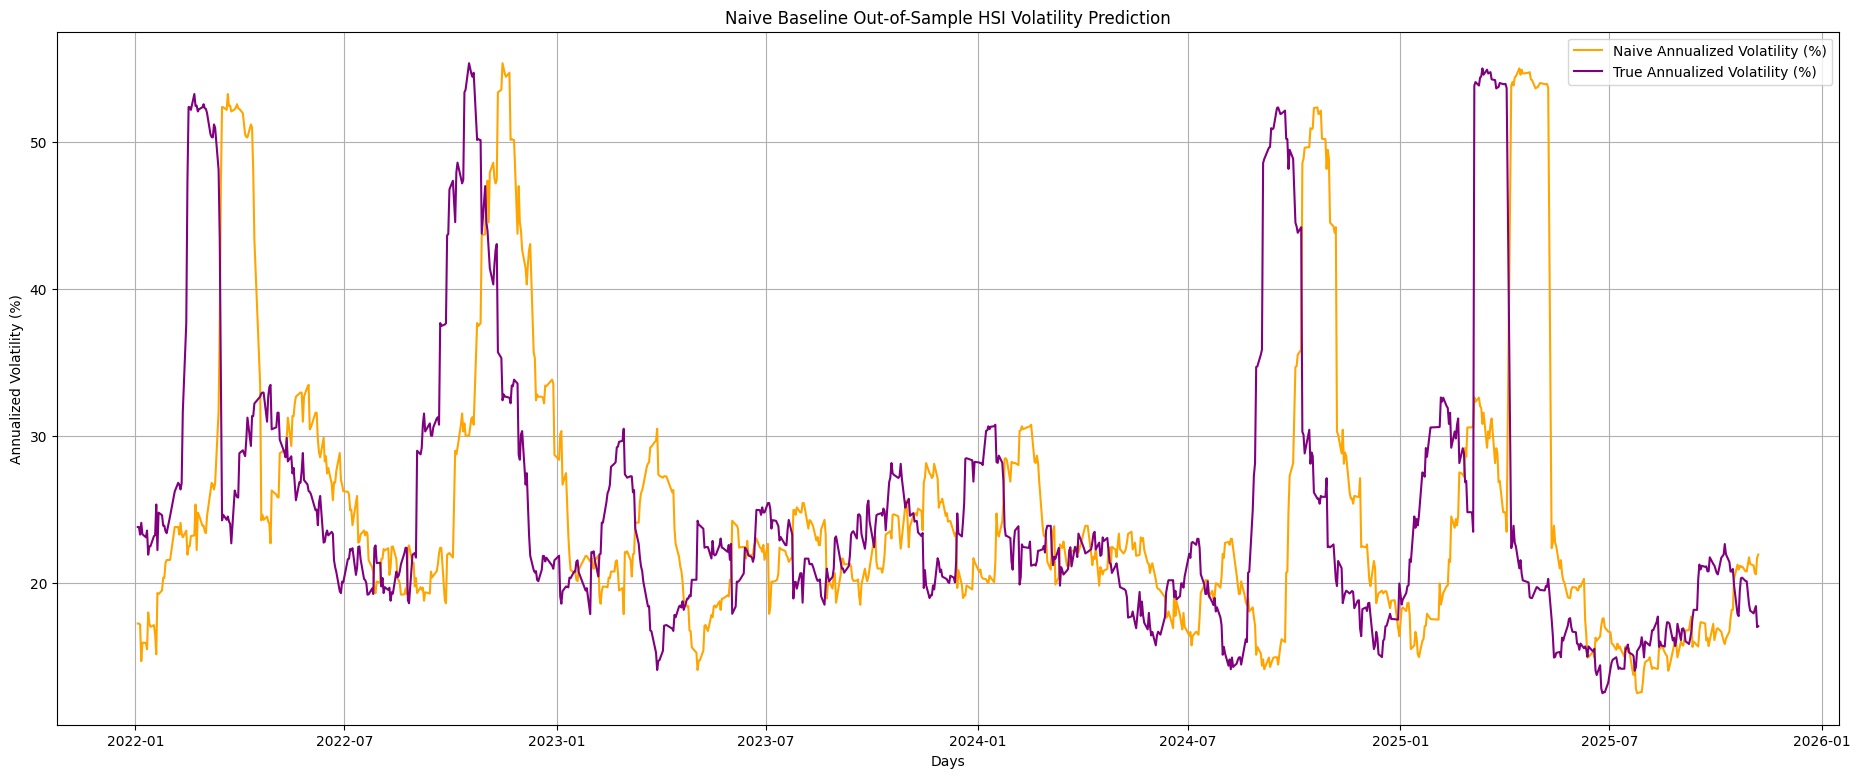

In [7]:
plt.figure(figsize=(23,9))

plt.plot(ann_pred, label='Naive Annualized Volatility (%)', c='orange')
plt.plot(ann_true, label='True Annualized Volatility (%)', c='purple')
plt.title('Naive Baseline Out-of-Sample HSI Volatility Prediction')
plt.xlabel('Days')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid()